In [9]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def download_data(tickers, start, end):

    df = yf.download(tickers, start=start, end=end)
    df_close = df['Close'].dropna(how='all')
    return df_close

def pair_trading_backtest(
    seriesA, seriesB,
    window,
    entry_k,
    exit_k
):

    df = pd.DataFrame({
        'A': seriesA,
        'B': seriesB
    }).dropna()

    # 스프레드 계산 (A - B)
    df['Spread'] = df['A'] - df['B']

    # 이동평균, 표준편차
    df['Spread_MA'] = df['Spread'].rolling(window=window).mean()
    df['Spread_STD'] = df['Spread'].rolling(window=window).std()

    # 포지션 상태: 0(무포지션), +1(롱 스프레드), -1(숏 스프레드)
    position = 0
    df['Position'] = 0
    df['Trade_PnL'] = 0.0  # 개별 트레이드(체결) 시점의 PnL 누적
    current_entry_spread = None

    for i in range(len(df)):
        if i < window:
            # 초기 window 기간은 signal 계산 불가
            continue

        ma = df['Spread_MA'].iloc[i]
        std = df['Spread_STD'].iloc[i]
        spread_now = df['Spread'].iloc[i]

        if position == 0:
            if spread_now > ma + entry_k * std:
                # 'Short Spread' 진입 (A 숏, B 롱)
                position = -1
                current_entry_spread = spread_now
            elif spread_now < ma - entry_k * std:
                # 'Long Spread' 진입 (A 롱, B 숏)
                position = +1
                current_entry_spread = spread_now

        else:
            # 스프레드가 ma ± exit_k * std 범위 안으로 돌아오면 청산
            upper_exit = ma + exit_k * std
            lower_exit = ma - exit_k * std

            if position == -1:
                # short spread
                if spread_now <= upper_exit:
                    # 청산
                    trade_pnl = current_entry_spread - spread_now
                    df['Trade_PnL'].iloc[i] = trade_pnl
                    position = 0
                    current_entry_spread = None

            elif position == +1:
                # long spread
                if spread_now >= lower_exit:
                    # 청산
                    trade_pnl = spread_now - current_entry_spread
                    df['Trade_PnL'].iloc[i] = trade_pnl
                    position = 0
                    current_entry_spread = None

        df['Position'].iloc[i] = position

    # Trade_PnL 컬럼이 0이 아닌 지점에서 포지션 청산이 이루어진 것
    df['CumPnL'] = df['Trade_PnL'].cumsum()

    return df

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['Position'].iloc[i] = position
<ipython-input-9-ce494aea76d0>:79: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Position'].iloc[i] = position
<ipython-input-9-ce494aea76d0>:79: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values 

최종 누적 PnL (JPM-BAC): 22.78
                     A          B     Spread  Spread_MA  Spread_STD  Position  \
Date                                                                            
2022-12-16  121.989510  29.979874  92.009636  93.720516    1.347238         0   
2022-12-19  122.716042  30.320341  92.395700  93.739794    1.324369         0   
2022-12-20  123.310455  30.443283  92.867172  93.660264    1.339491         0   
2022-12-21  124.697479  30.906696  93.790783  93.593687    1.303699         0   
2022-12-22  123.282158  30.632431  92.649727  93.504976    1.320668         0   
2022-12-23  123.867142  30.708094  93.159048  93.488523    1.323526         0   
2022-12-27  124.301170  30.764833  93.536337  93.634112    1.184599         0   
2022-12-28  124.980522  30.991812  93.988710  93.703339    1.172058         0   
2022-12-29  125.697617  31.341730  94.355886  93.786312    1.171206         0   
2022-12-30  126.527946  31.322823  95.205124  93.820180    1.206245         0   



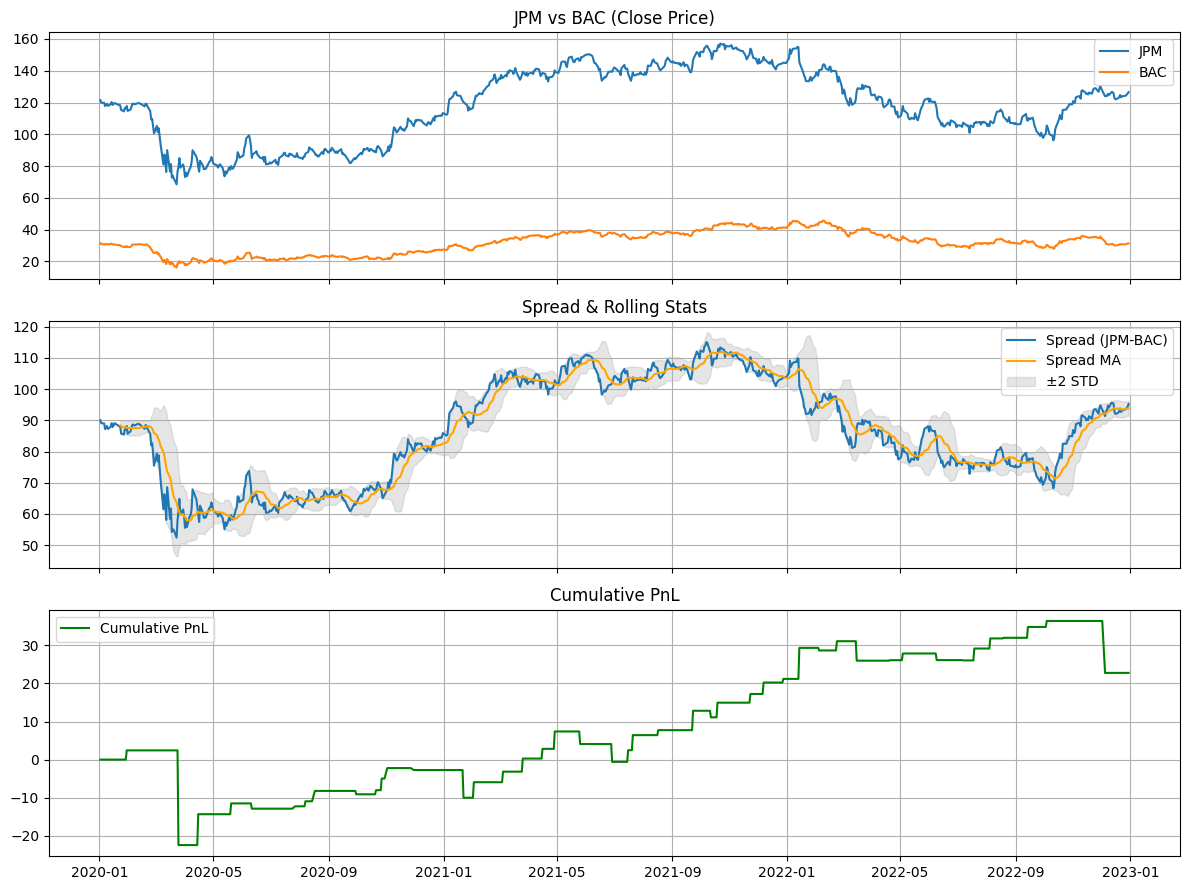

In [11]:

tickers = ['JPM', 'BAC', 'WFC', 'GS']
# 1) yfinance로 데이터 다운로드
df_close = download_data(tickers, start="2020-01-01", end="2023-01-01")

  # 예시: JPM, BAC를 페어로 선택 (간단하게)
jpm = df_close['JPM']
bac = df_close['BAC']

  # 2) 페어 트레이딩 백테스트 실행
result_df = pair_trading_backtest(
    seriesA=jpm,
    seriesB=bac,
    window=15,
    entry_k=1.8,
    exit_k=0.2
)

  # 3) 결과 출력
final_pnl = result_df['CumPnL'].iloc[-1]
print(f"최종 누적 PnL (JPM-BAC): {final_pnl:.2f}")
print(result_df.tail(10))

    # 4) 시각화
fig, axs = plt.subplots(3,1,figsize=(12,9), sharex=True)
axs[0].plot(result_df.index, result_df['A'], label='JPM')
axs[0].plot(result_df.index, result_df['B'], label='BAC')
axs[0].set_title("JPM vs BAC (Close Price)")
axs[0].legend()
axs[0].grid(True)

axs[1].plot(result_df.index, result_df['Spread'], label='Spread (JPM-BAC)')
axs[1].plot(result_df.index, result_df['Spread_MA'], label='Spread MA', color='orange')
axs[1].fill_between(
    result_df.index,
    result_df['Spread_MA'] - 2*result_df['Spread_STD'],
    result_df['Spread_MA'] + 2*result_df['Spread_STD'],
    color='gray', alpha=0.2, label='±2 STD'
)
axs[1].set_title("Spread & Rolling Stats")
axs[1].legend()
axs[1].grid(True)

axs[2].plot(result_df.index, result_df['CumPnL'], label='Cumulative PnL', color='green')
axs[2].set_title("Cumulative PnL")
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()